In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import pyfolio as pf
import yfinance as yf
import riskfolio as rp
import ffn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# directory of the library 
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [3]:
from myPortfolioManagement.myData import get_US_yields, get_US_yield_spreads, get_fred_data
from myPortfolioManagement.myPlots import correlation_matrix

# The US Yield Curve 

## Summarizing and Interpreting the Behavior of the Yield Curve 

Yields are correlated to each other, meaning that there are common factors that drivers their behavior.  The easiest way to summarize the common information contained in the yield curve is to use PCA. 

In most applications PCA factors do not have particular meaning or interpretation. When applying the PCA to the yield curve, however, the **first three** factors have a specific meaning and explain most of the variation in the behavior of the yields (at each point of time). 

- **Level or shift factors**: When the first principle component increases by a positive quantity all yields increase and hence the yield curve shifts upwards. 
- **Slope factors**: when the second principle component increases by a positive quantity this implies that the front end of the yield curve shifts upwards while the other end shifts downwards implying that the impact is mostly on the slope.
- **Curvature Factors**:  when the third principle component increases by a positive quantity this implies that the short and long ends of the yield curve shift upwards while the middle part shifts downwards implying a change in the curvature.

In [4]:
# yields for the US Treasuries 
frequency = 'm' # monthly frequency 

yields = get_US_yields(freq = frequency, add_fed_rate=True)

# Spreads of US Treasuries relative to 10Y
spreads = get_US_yield_spreads(freq = frequency)

# Download Data From Fed St. Louis. Here I download the Total Amount of QE 
# The Ticker of the series are the ones Fed St. Louis is using 

QE = get_fred_data(['WALCL'], freq = frequency)
QE = QE.rename(columns={'WALCL': 'QE'})
QE['qe_growth'] = QE.pct_change()

In [5]:
yield_daily = get_US_yields(freq = 'd', add_fed_rate=True)
yield_daily.tail()

,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y,EFFR
Date,,,,,,,,,,,,
2023-01-06,4.32,4.67,4.79,4.71,4.24,3.96,3.69,3.63,3.55,3.84,3.67,4.33
2023-01-09,4.37,4.70,4.83,4.69,4.19,3.93,3.66,3.60,3.53,3.83,3.66,4.33
2023-01-10,4.41,4.73,4.85,4.74,4.24,3.94,3.72,3.67,3.61,3.91,3.74,4.33
2023-01-11,4.42,4.72,4.84,4.73,4.20,3.90,3.66,3.61,3.54,3.84,3.67,4.33
2023-01-12,4.57,4.66,4.76,4.66,4.12,3.79,3.53,3.48,3.43,3.73,3.56,4.33


In [6]:
# Annual Frequency 
yields_yearly = get_US_yields(freq = 'a', add_fed_rate=True)
yields_yearly

,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y,EFFR
Date,,,,,,,,,,,,
1962-01-01,NaN,NaN,NaN,3.10,NaN,3.47,3.70,NaN,3.95,3.99,NaN,NaN
1963-01-01,NaN,NaN,NaN,3.36,NaN,3.67,3.83,NaN,4.00,4.05,NaN,NaN
1964-01-01,NaN,NaN,NaN,3.85,NaN,4.03,4.07,NaN,4.19,4.19,NaN,NaN
1965-01-01,NaN,NaN,NaN,4.15,NaN,4.22,4.25,NaN,4.28,4.27,NaN,NaN
1966-01-01,NaN,NaN,NaN,5.20,NaN,5.23,5.11,NaN,4.93,4.77,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-01,2.12,2.11,2.11,2.05,1.97,1.94,1.95,2.05,2.14,2.40,2.58,2.16
2020-01-01,0.35,0.36,0.37,0.37,0.39,0.42,0.53,0.72,0.89,1.35,1.56,0.36
2021-01-01,0.04,0.04,0.06,0.10,0.27,0.46,0.86,1.20,1.45,1.98,2.06,0.08


<AxesSubplot:title={'center':'QE and 10-Year US Treasury yields'}, xlabel='Date'>

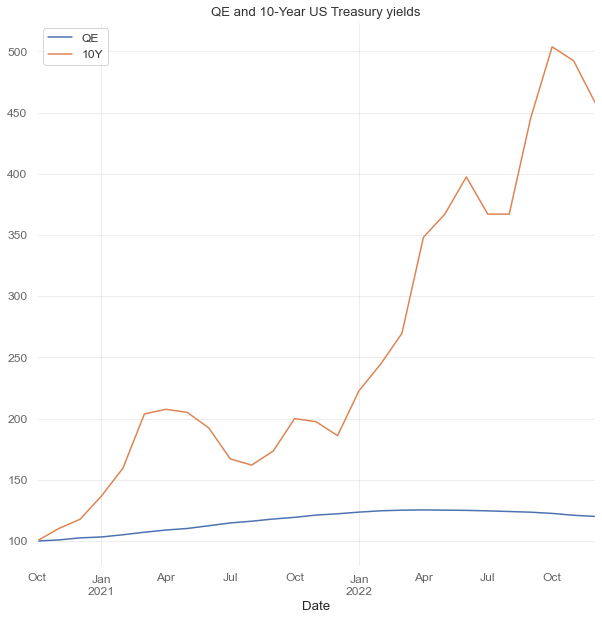

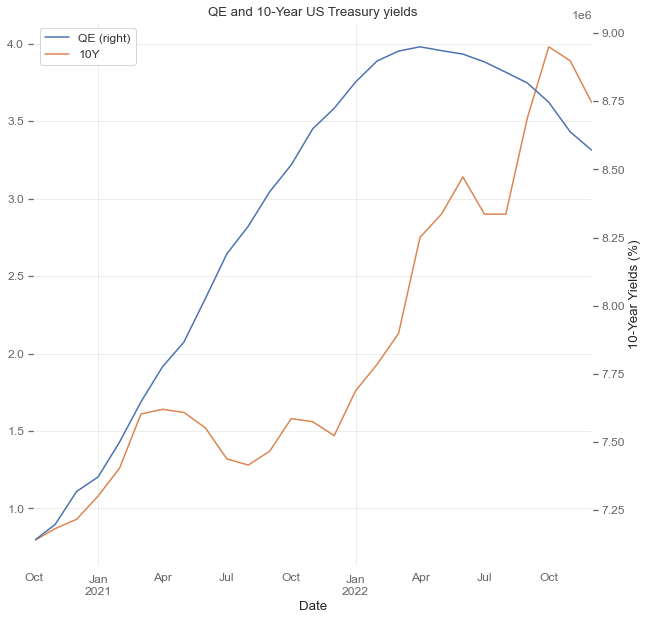

In [7]:
df = pd.concat([QE.dropna(), yields], axis= 1)

df_temp = df[['QE', '10Y']]

df_temp[df_temp.index>='2020-10-01'].dropna().rebase().plot(title = 'QE and 10-Year US Treasury yields',figsize = (10,10))
df_temp[df_temp.index>='2020-10-01'].dropna().plot(title = 'QE and 10-Year US Treasury yields',
                                                   figsize = (10,10), 
                                                   secondary_y = 'QE', 
                                                   ylabel= '10-Year Yields (%)')


Text(0, 0.5, 'QE (Mill USD)')

<Figure size 432x288 with 0 Axes>

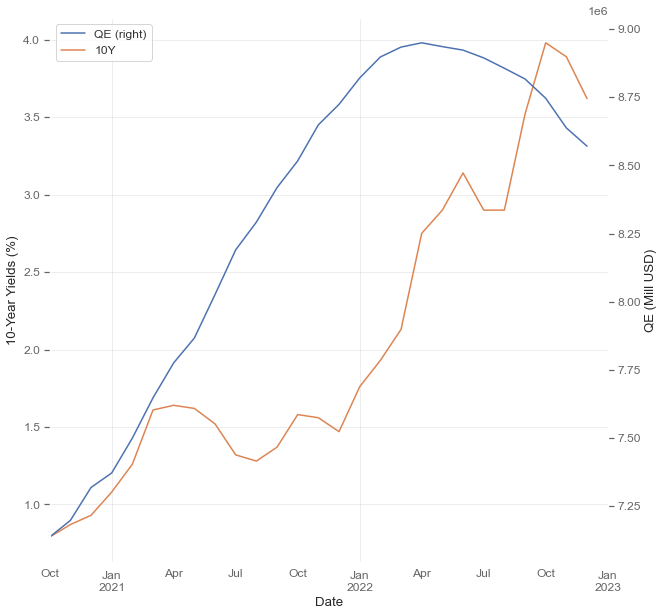

In [8]:
plt.figure()
ax = df_temp[df_temp.index>='2020-10-01'].plot(secondary_y=['QE'], figsize = (10,10))
ax.set_ylabel('10-Year Yields (%)')
ax.right_ax.set_ylabel('QE (Mill USD)')

In [9]:
df_temp[df_temp.index>='2020-10-01'].dropna()
df_temp[df_temp.index>='2020-10-01'].dropna().rebase()

,QE,10Y
Date,,
2020-10-01,100.000000,100.000000
2020-11-01,100.850476,110.126582
2020-12-01,102.544326,117.721519
2021-01-01,103.288993,136.708861
2021-02-01,105.081282,159.493671
2021-03-01,107.152396,203.797468
2021-04-01,108.946688,207.594937
2021-05-01,110.220525,205.063291
2021-06-01,112.457499,192.405063


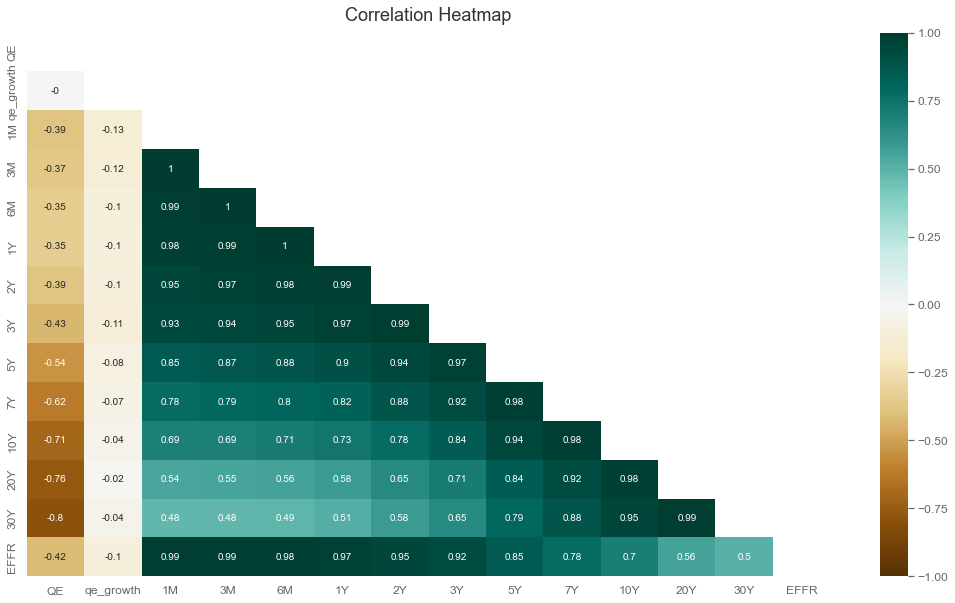

In [10]:
correlation_matrix(df.dropna(), diagonal = True)

## Correlation between Spreads (These two spreads commonly used to predict recessions)

<AxesSubplot:xlabel='Date'>

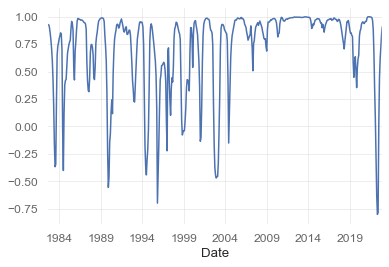

In [13]:
s1 = spreads['spread_10Y_3M']
s2 = spreads['spread_10Y_2Y']
s3= s1.rolling(12).corr(s2)
s3.dropna().plot()

In [15]:
s1 = spreads['spread_10Y_3M'].rolling(12).mean()
s2 = spreads['spread_10Y_2Y'].rolling(12).mean()
s2.corr(s1)

0.8774083375434489

In [17]:
## Cluster of Spreads

<Axes:>

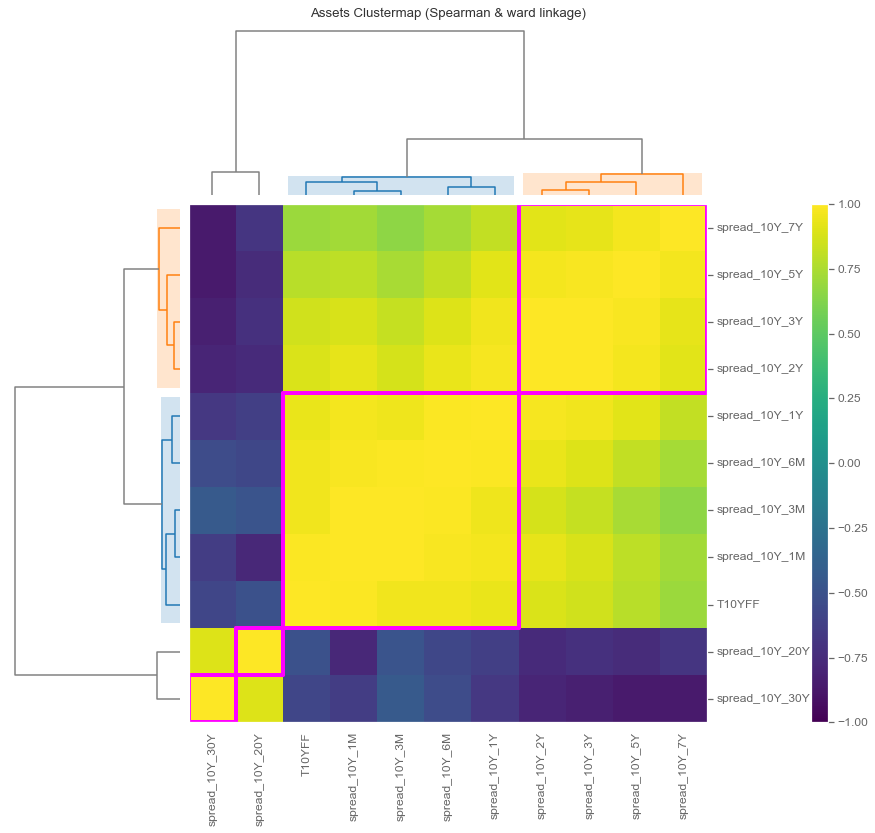

In [18]:
rp.plot_clusters(returns=spreads, codependence="spearman",
                      linkage='ward', leaf_order=True, dendrogram=True, ax=None)

In [19]:
import scipy.stats as stats
from sklearn import cluster, metrics
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet, fcluster
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_samples, silhouette_score

In [21]:
# Standardising the data
X = pd.DataFrame(spreads.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pd.DataFrame(X))
# Transformed the arrays of scaled values into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [22]:
hier_comp = linkage(X_scaled, method='complete', metric='euclidean')
hier_average = linkage(X_scaled, method='average', metric='euclidean')
hier_ward = linkage(X_scaled, method='ward', metric='euclidean')


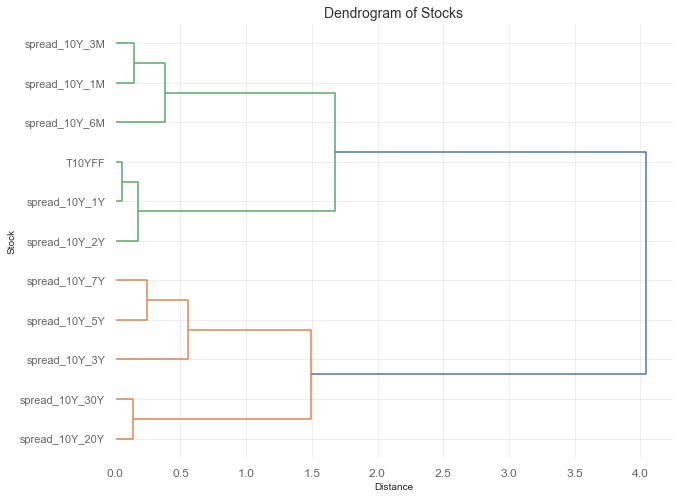

In [24]:
plt.figure(figsize=(10, 8))
plt.title('Dendrogram of Stocks', fontsize=14)
plt.xlabel('Distance', fontsize=10)
plt.ylabel('Stock', fontsize=10)
dendrogram(
    hier_ward,
    orientation='right',
      #   leaf_rotation=90.,
    leaf_font_size=20,
    labels=X_scaled.index.values,
    color_threshold=3
)
plt.yticks(fontsize=11)
plt.show()

In [ ]:
df_spreads = yields[1]
df_spreads.tail()

In [ ]:
df_yields = yields[0]
df_yields_factors = yields[1]